In [2]:
!pip install datasets sentencepiece sacrebleu rouge-score torch

In [3]:
from datasets import load_dataset
ds=load_dataset("uqa/UQA")
print(ds)

ex=ds["train"][0]
print(ex.keys())

print(ex["question"])
print(ex["answer"])

n_total=len(ds["train"])
n_ans=sum(len(a)>0 for a in ds["train"]["answer"] if a is not None)
print(f"train rows: {n_total}, answerable: {n_ans}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file:   0%|          |  0.00B / 30.2MB            

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-cf8a6960d(…): reconstructing file:   0%|          |  0.00B / 2.92MB            

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/124745 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16824 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})
dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
1990 کی دہائی کے آخر میں
train rows: 124745, answerable: 83018


In [4]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

drive.mount('/content/drive')
DRIVE_DIR = Path('/content/drive/MyDrive/GenAI-Dataset (1)')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

ANS_OPEN = "<ans>"
ANS_CLOSE = "</ans>"
SENT_DELIMS = "\u06D4\u061F!" 

def split_sentences(text):
  start = 0
  for i, ch in enumerate(text):
    if ch in SENT_DELIMS:
      yield start, i + 1, text[start : i + 1]
      start = i + 1
  if start < len(text):
    yield start, len(text), text[start:]

def make_pair(example, max_src=60, max_tgt=25):
  answer = example["answer"]
  # Skip unanswerable questions
  if not answer or len(answer) == 0:
    return None
  a_start = example["answer_start"]
  a_text = answer
  context = example["context"]
  for s, e, sent in split_sentences(context):
    # Check if answer starts inside this sentence
    if s <= a_start < e:
      rel = a_start - s  # Offset inside this specific sentence
      # Integrity check: does the text at this slice match the answer text?
      if sent[rel : rel + len(a_text)] != a_text:
        return None  # Offset mismatch -> skip
      # Insert the <ans> tags
      src = (
          sent[:rel]
          + " "
          + ANS_OPEN
          + " "
          + a_text
          + " "
          + ANS_CLOSE
          + " "
          + sent[rel + len(a_text) :]
      ).strip()
      # Normalise extra whitespaces
      src = " ".join(src.split())
      tgt = " ".join(example["question"].split())
      # Apply length filters (whitespace tokens)
      src_len = len(src.split())
      tgt_len = len(tgt.split())
      if src_len > max_src or tgt_len > max_tgt:
        return None
      return src, tgt
  return None


In [5]:
def build_split(split, out_path):
  pairs = [p for p in map(make_pair, split) if p is not None]
  with open(out_path, "w", encoding="utf-8", newline="") as f:
    w = csv.writer(
        f, delimiter="\t", quoting=csv.QUOTE_NONE, escapechar="\\"
    )
    w.writerows(pairs)
  print(f"{out_path}: {len(pairs)} pairs")
  return pairs
# Build train and valid
train_pairs = build_split(ds["train"], DRIVE_DIR / "train.tsv")
valid_pairs = build_split(ds["validation"], DRIVE_DIR / "valid.tsv")


wiki_ds = load_dataset("uqa/Wiki-UQA")

wiki_split = wiki_ds["train"]
wiki_pairs = build_split(wiki_split, DRIVE_DIR / "wiki_test.tsv")

#inspecting the first 3 pairs
for i in range(3):
  src, tgt = train_pairs[i]
  print(f"{i+1} : ")
  print("Source (Sentence + <ans>):", src)
  print("Target (Question):         ", tgt)

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


README.md:   0%|          | 0.00/489 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 76.0kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/210 [00:00<?, ? examples/s]

wiki_test.tsv: 177 pairs
1 : 
Source (Sentence + <ans>): ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
Target (Question):          بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
2 : 
Source (Sentence + <ans>): ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں آر اینڈ بی گرل گروپ ڈسٹنی چائلڈ کی لیڈ گلوکارہ کی حیثیت سے شہرت حاصل کی۔
Target (Question):          جب وہ بڑی ہو رہی تھی تو بیونس نے کن شعبوں میں مقابلہ کیا؟
3 : 
Source (Sentence + <ans>): ان کے وقفے نے بیونس کی پہلی البم ، خطرناک طور پر محبت ( <ans> 2003 </ans> ) کی رہائی دیکھی ، جس نے اسے دنیا بھر میں ایک سولو آرٹسٹ کے طور پر قائم کیا ، پانچ گریمی ایوارڈز حاصل کیے اور بل بورڈ ہاٹ 100 میں نمبر ون سنگلز میں پاگل محبت اور بیبی بوائے۔
Target (Question):          بیونسی نے

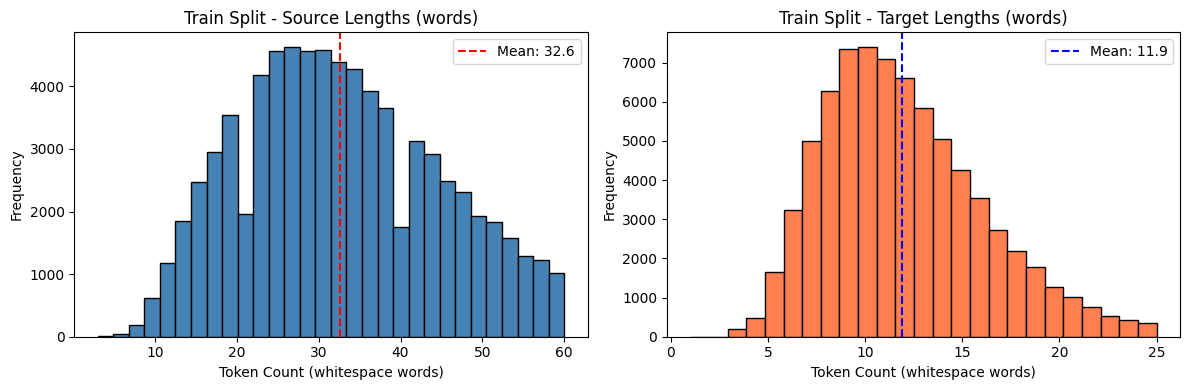

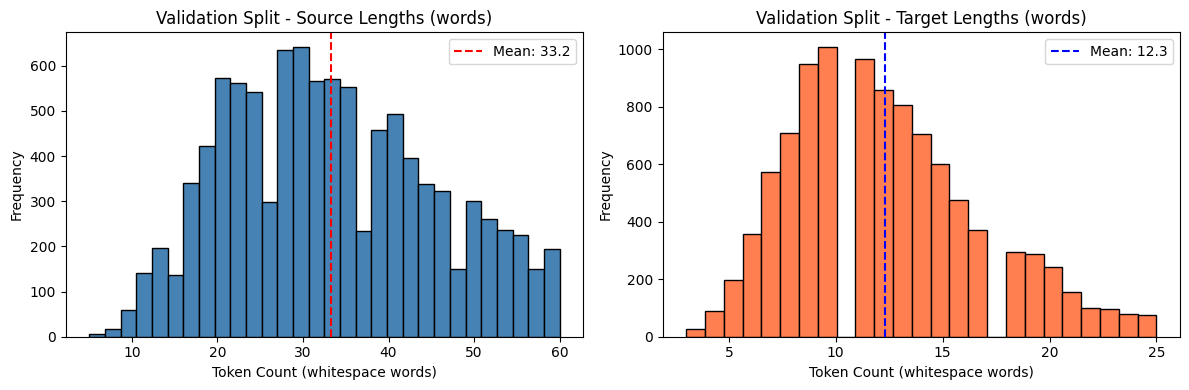

In [6]:
# Plot length histograms for Train and Validation pairs
def plot_histograms(pairs, split_name="Train"):
    src_lens = [len(src.split()) for src, tgt in pairs]
    tgt_lens = [len(tgt.split()) for src, tgt in pairs]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Source length histogram
    axes[0].hist(src_lens, bins=30, color="steelblue", edgecolor="black")
    axes[0].set_title(f"{split_name} - Source Lengths (words)")
    axes[0].set_xlabel("Token Count (whitespace words)")
    axes[0].set_ylabel("Frequency")
    axes[0].axvline(np.mean(src_lens), color="red", linestyle="--", label=f"Mean: {np.mean(src_lens):.1f}")
    axes[0].legend()

    # Target length histogram
    axes[1].hist(tgt_lens, bins=25, color="coral", edgecolor="black")
    axes[1].set_title(f"{split_name} - Target Lengths (words)")
    axes[1].set_xlabel("Token Count (whitespace words)")
    axes[1].set_ylabel("Frequency")
    axes[1].axvline(np.mean(tgt_lens), color="blue", linestyle="--", label=f"Mean: {np.mean(tgt_lens):.1f}")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(DRIVE_DIR / f"{split_name.lower()}_length_histogram.png", dpi=160)
    plt.show()

plot_histograms(train_pairs, "Train Split")
plot_histograms(valid_pairs, "Validation Split")